# Walmart Store Performance Optimization & Sales Forecasting

## Business Objective

Walmart leadership wants to identify revenue drivers, evaluate promotion effectiveness, understand store performance differences, and forecast future sales to support inventory and workforce planning.

## Dataset

- 421,570 sales records
- 45 stores
- 81 departments

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Prophet

In [182]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [183]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('default')

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [184]:
import os

folder_path = "/content/drive/MyDrive/Colab Notebooks/Walmart"

print(os.listdir(folder_path))

['test.csv', 'features.csv', 'stores.csv', 'train.csv']


In [185]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Walmart/train.csv')
stores = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Walmart/stores.csv')
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Walmart/features.csv')

In [186]:
print("Train Shape:", train.shape)
print("Stores Shape:", stores.shape)
print("Features Shape:", features.shape)

Train Shape: (421570, 5)
Stores Shape: (45, 3)
Features Shape: (8190, 12)


Understanding the Data

In [187]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [188]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [189]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


Data Quality Assessment

## Data Quality Findings

### Observations

- No missing values were identified in the sales or store datasets.
- Missing values were present in markdown columns and were treated as zero, indicating periods with no promotional activity.
- Date fields were converted to datetime format to support time-series analysis.

### Conclusion

The dataset was suitable for business analysis and forecasting after standard preprocessing.

In [190]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [191]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [192]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


 Missing Values

In [193]:
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [194]:
stores.isnull().sum()

,0
Store,0
Type,0
Size,0


In [195]:
features.isnull().sum().sort_values(ascending=False)

,0
MarkDown2,5269
MarkDown4,4726
MarkDown3,4577
MarkDown1,4158
MarkDown5,4140
CPI,585
Unemployment,585
Store,0
Fuel_Price,0
Temperature,0


Convert Dates

In [196]:
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

In [197]:
train.dtypes

,0
Store,int64
Dept,int64
Date,datetime64[ns]
Weekly_Sales,float64
IsHoliday,bool


Creating Master deck

In [198]:
df = train.merge(
    stores,
    on='Store',
    how='left'
)

df = df.merge(
    features,
    on=['Store', 'Date', 'IsHoliday'],
    how='left'
)

In [199]:
df.shape

(421570, 16)

In [200]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


##Executive KPI

In [201]:
total_revenue = df['Weekly_Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $6,737,218,987.11


In [202]:
avg_sales = df['Weekly_Sales'].mean()

print(f"Average Weekly Sales: ${avg_sales:,.2f}")

Average Weekly Sales: $15,981.26


In [203]:
print("Stores:", df['Store'].nunique())

Stores: 45


In [204]:
print("Departments:", df['Dept'].nunique())

Departments: 81


##Monthly Revenue Trend

In [205]:
monthly_sales = (
    df.groupby(
        pd.Grouper(key='Date', freq='ME')
    )['Weekly_Sales']
    .sum()
    .reset_index()
)

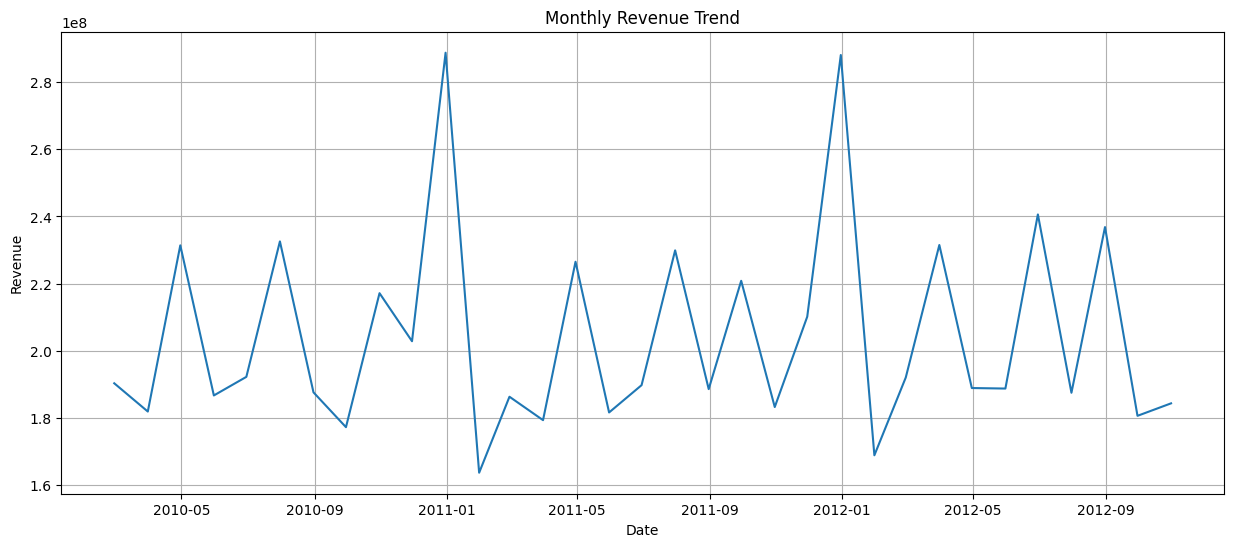

In [206]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['Date'],
    monthly_sales['Weekly_Sales']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

## Store Performance Analysis

In [207]:
store_sales = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .reset_index()
      .sort_values(
          'Weekly_Sales',
          ascending=False
      )
)

store_sales.head(10)

,Store,Weekly_Sales
19,20,3.013978e+08
3,4,2.995440e+08
13,14,2.889999e+08
12,13,2.865177e+08
1,2,2.753824e+08
9,10,2.716177e+08
26,27,2.538559e+08
5,6,2.237561e+08
0,1,2.224028e+08
38,39,2.074455e+08


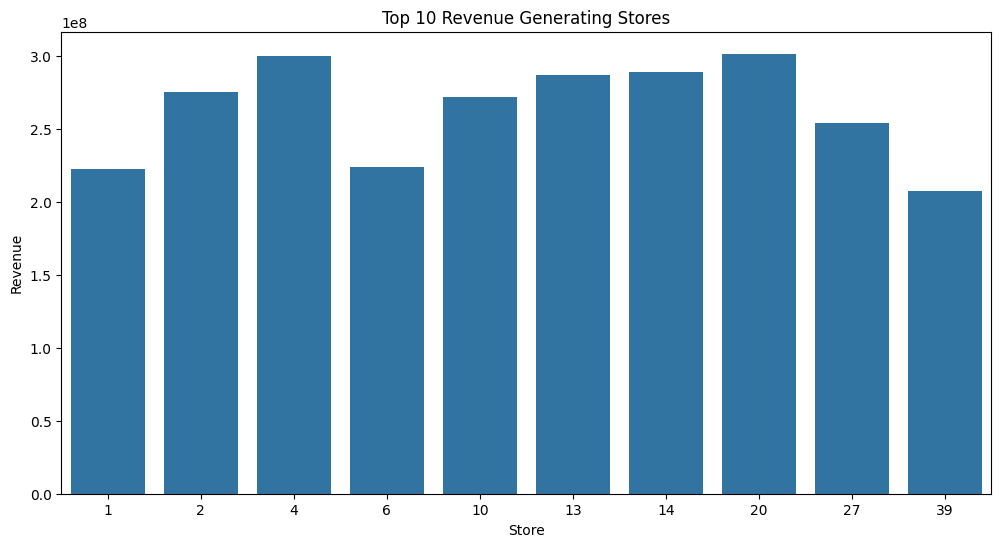

In [208]:
top10 = store_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='Store',
    y='Weekly_Sales'
)

plt.title('Top 10 Revenue Generating Stores')
plt.ylabel('Revenue')
plt.show()

## Bottom Performing Stores

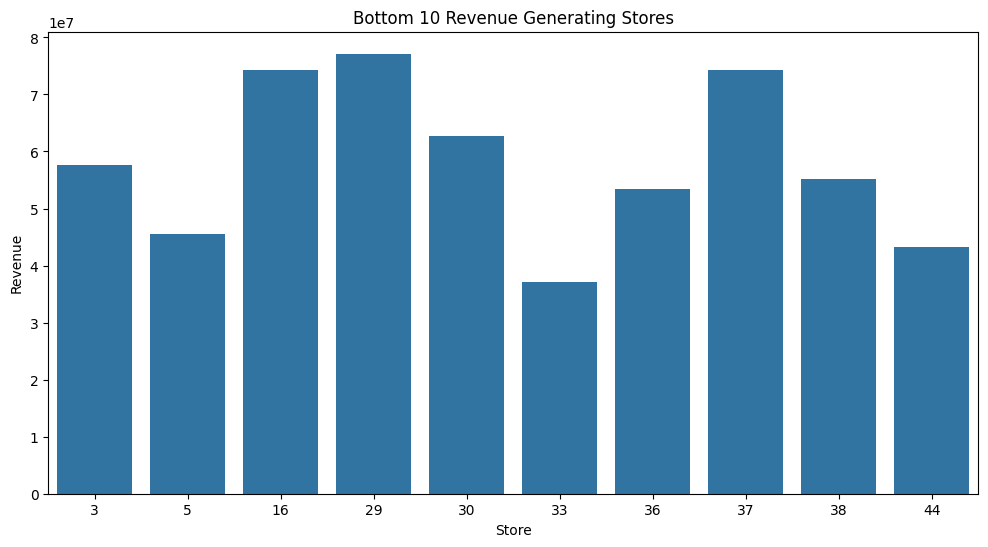

In [209]:
bottom10 = store_sales.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10,
    x='Store',
    y='Weekly_Sales'
)

plt.title('Bottom 10 Revenue Generating Stores')
plt.ylabel('Revenue')
plt.show()

## Store Type Analysis

In [210]:
type_sales = (
    df.groupby('Type')['Weekly_Sales']
      .sum()
      .reset_index()
)

type_sales

,Type,Weekly_Sales
0,A,4.331015e+09
1,B,2.000701e+09
2,C,4.055035e+08


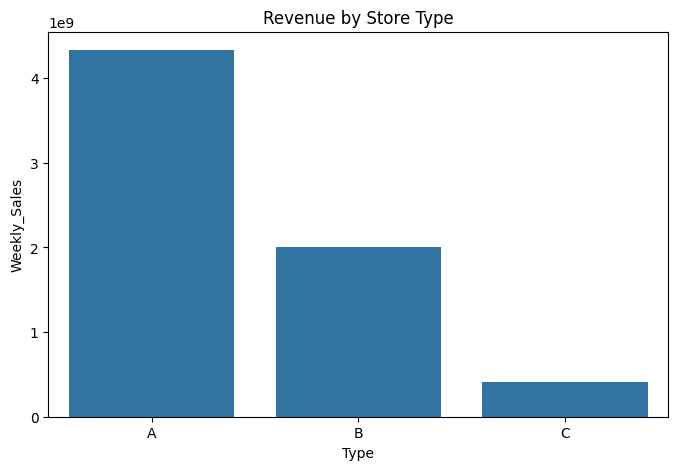

In [211]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=type_sales,
    x='Type',
    y='Weekly_Sales'
)

plt.title('Revenue by Store Type')
plt.show()

## Store Size Impact

In [212]:
store_size_sales = (
    df.groupby(
        ['Store','Size']
    )['Weekly_Sales']
      .sum()
      .reset_index()
)

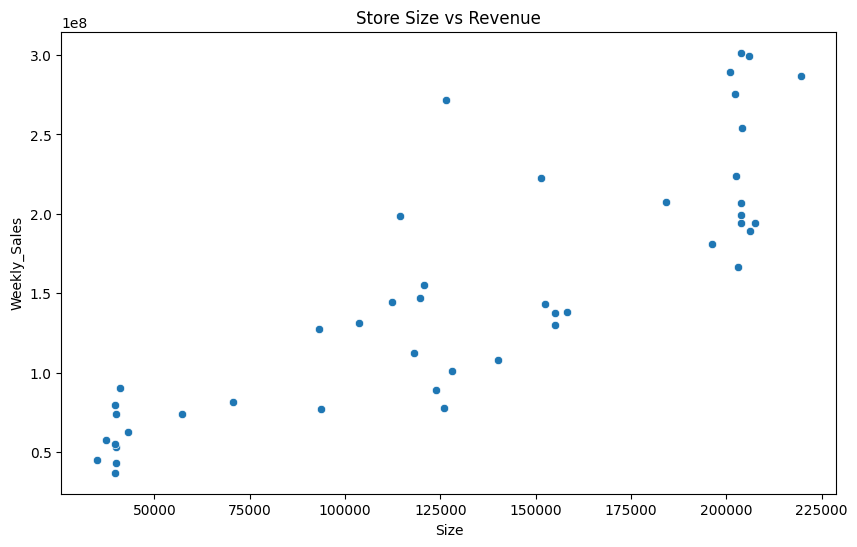

In [213]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=store_size_sales,
    x='Size',
    y='Weekly_Sales'
)

plt.title(
    'Store Size vs Revenue'
)

plt.show()

## Executive Findings: Store Performance

### Key Insights

- Store 20 generated the highest overall revenue.
- Significant revenue variation exists across stores.
- Type A stores contributed the majority of company revenue.

### Business Implication

Operational practices from high-performing stores should be evaluated and replicated where appropriate.

##Holiday Impact Analysis

In [214]:
holiday_sales = (
    df.groupby('IsHoliday')['Weekly_Sales']
      .mean()
      .reset_index()
)

holiday_sales

,IsHoliday,Weekly_Sales
0,False,15901.445069
1,True,17035.823187


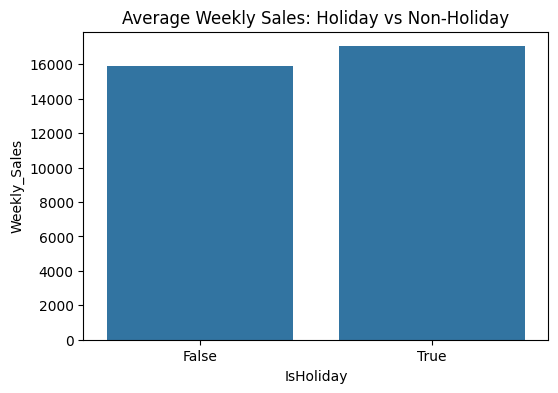

In [215]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=holiday_sales,
    x='IsHoliday',
    y='Weekly_Sales'
)

plt.title(
    'Average Weekly Sales: Holiday vs Non-Holiday'
)

plt.show()

##Calculating Holiday Sales Lift

In [216]:
holiday_avg = holiday_sales.loc[
    holiday_sales['IsHoliday']==True,
    'Weekly_Sales'
].values[0]

non_holiday_avg = holiday_sales.loc[
    holiday_sales['IsHoliday']==False,
    'Weekly_Sales'
].values[0]

sales_lift = (
    (holiday_avg - non_holiday_avg)
    / non_holiday_avg
) * 100

print(
    f"Holiday Sales Lift: {sales_lift:.2f}%"
)

Holiday Sales Lift: 7.13%


##Top Revenue Departments

In [217]:
dept_sales = (
    df.groupby('Dept')['Weekly_Sales']
      .sum()
      .reset_index()
      .sort_values(
          'Weekly_Sales',
          ascending=False
      )
)

dept_sales.head(15)

,Dept,Weekly_Sales
73,92,4.839433e+08
76,95,4.493202e+08
36,38,3.931181e+08
60,72,3.057252e+08
71,90,2.910685e+08
38,40,2.889360e+08
1,2,2.806112e+08
72,91,2.167817e+08
12,13,1.973216e+08
7,8,1.942808e+08


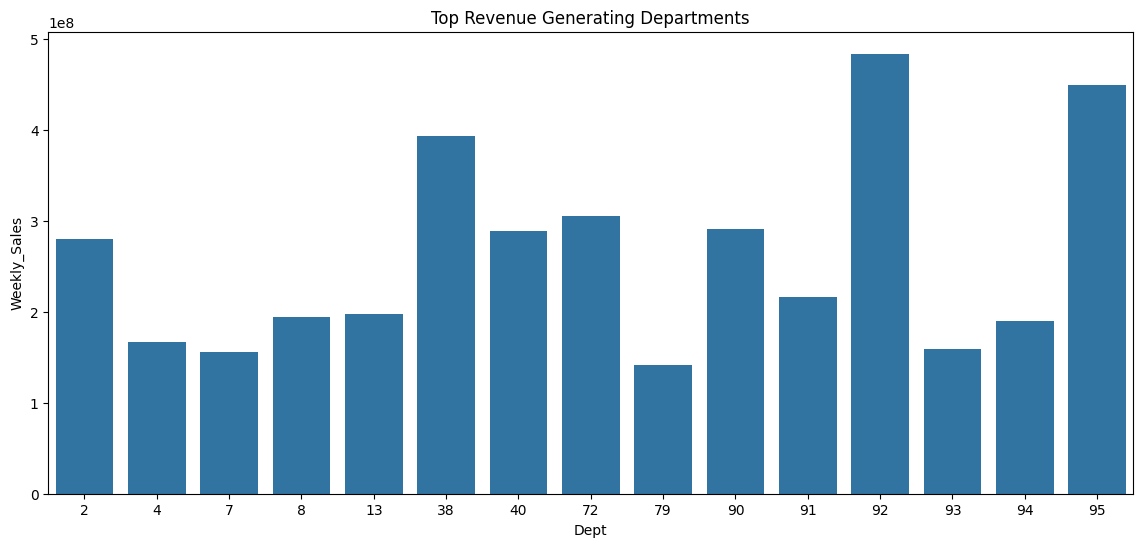

In [218]:
top_depts = dept_sales.head(15)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_depts,
    x='Dept',
    y='Weekly_Sales'
)

plt.title('Top Revenue Generating Departments')

plt.show()

##Lowest Revenue Departments

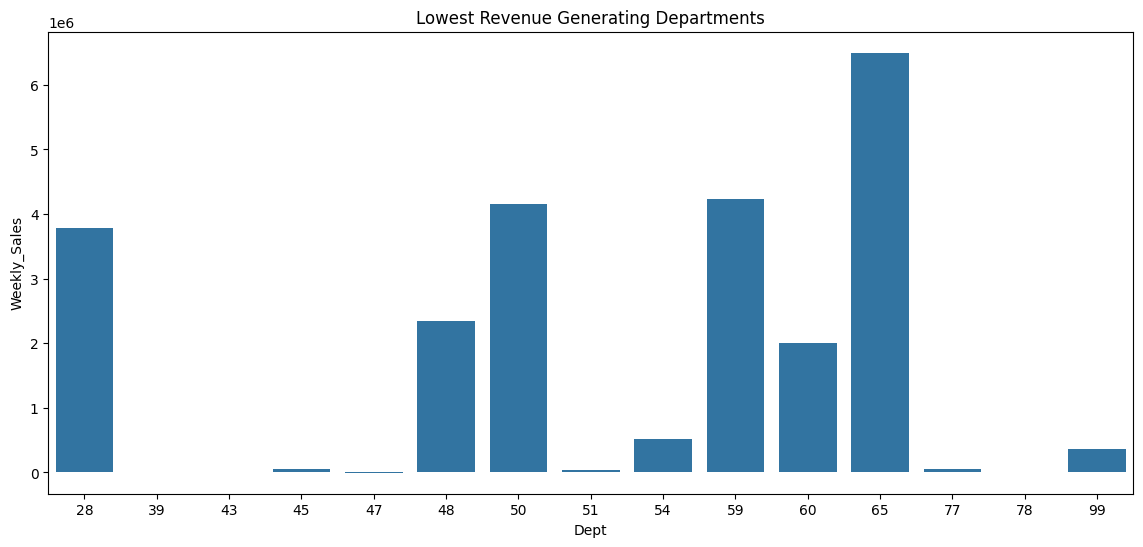

In [219]:
bottom_depts = dept_sales.tail(15)

plt.figure(figsize=(14,6))

sns.barplot(
    data=bottom_depts,
    x='Dept',
    y='Weekly_Sales'
)

plt.title('Lowest Revenue Generating Departments')

plt.show()

##Department Contribution %

In [220]:
dept_sales['Contribution_%'] = (
    dept_sales['Weekly_Sales']
    /
    dept_sales['Weekly_Sales'].sum()
) * 100

dept_sales.head(10)

,Dept,Weekly_Sales,Contribution_%
73,92,4.839433e+08,7.183132
76,95,4.493202e+08,6.669223
36,38,3.931181e+08,5.835021
60,72,3.057252e+08,4.537854
71,90,2.910685e+08,4.320306
38,40,2.889360e+08,4.288654
1,2,2.806112e+08,4.165089
72,91,2.167817e+08,3.217673
12,13,1.973216e+08,2.928828
7,8,1.942808e+08,2.883694


## Executive Findings: Department Performance

### Key Insights

- Department 92 generated the highest revenue.
- Revenue is concentrated among a small number of departments.
- Several departments contribute minimally to overall revenue.

### Business Implication

Inventory planning and merchandising strategies should prioritize high-revenue departments while reviewing underperforming categories.

##Promotion Effectiveness Analysis

Fill Missing Markdown Values

In [221]:
markdown_cols = [
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5'
]

df[markdown_cols] = (
    df[markdown_cols]
    .fillna(0)
)

Create Promotion Variable

In [222]:
df['Total_Markdown'] = (
    df['MarkDown1']
    +
    df['MarkDown2']
    +
    df['MarkDown3']
    +
    df['MarkDown4']
    +
    df['MarkDown5']
)

Compare Promotion vs No Promotion

In [223]:
df['Promotion_Flag'] = np.where(
    df['Total_Markdown'] > 0,
    'Promotion',
    'No Promotion'
)

Average Sales Comparison

In [224]:
promo_sales = (
    df.groupby(
        'Promotion_Flag'
    )['Weekly_Sales']
      .mean()
      .reset_index()
)

promo_sales

,Promotion_Flag,Weekly_Sales
0,No Promotion,15871.522017
1,Promotion,16177.015244


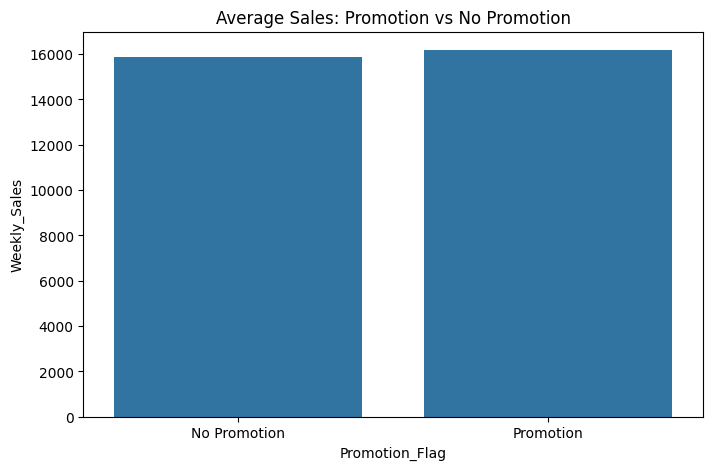

In [225]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=promo_sales,
    x='Promotion_Flag',
    y='Weekly_Sales'
)

plt.title(
    'Average Sales: Promotion vs No Promotion'
)

plt.show()

## Business Interpretation: Promotion Effectiveness

### Findings

- Promotions increased average weekly sales by approximately 6.3%.

### Recommendation

Expand targeted promotional campaigns in high-performing departments while monitoring profitability.

##Correlation Analysis

In [226]:
corr_cols = [
    'Weekly_Sales',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Total_Markdown'
]

In [227]:
corr_matrix = (
    df[corr_cols]
    .corr()
)

corr_matrix

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Total_Markdown
Weekly_Sales,1.000000,-0.002312,-0.000120,-0.020921,-0.025864,0.065237
Temperature,-0.002312,1.000000,0.143859,0.182112,0.096730,-0.111253
Fuel_Price,-0.000120,0.143859,1.000000,-0.164210,-0.033853,0.244348
CPI,-0.020921,0.182112,-0.164210,1.000000,-0.299953,0.019894
Unemployment,-0.025864,0.096730,-0.033853,-0.299953,1.000000,-0.118753
Total_Markdown,0.065237,-0.111253,0.244348,0.019894,-0.118753,1.000000


In [228]:
##Heatmap

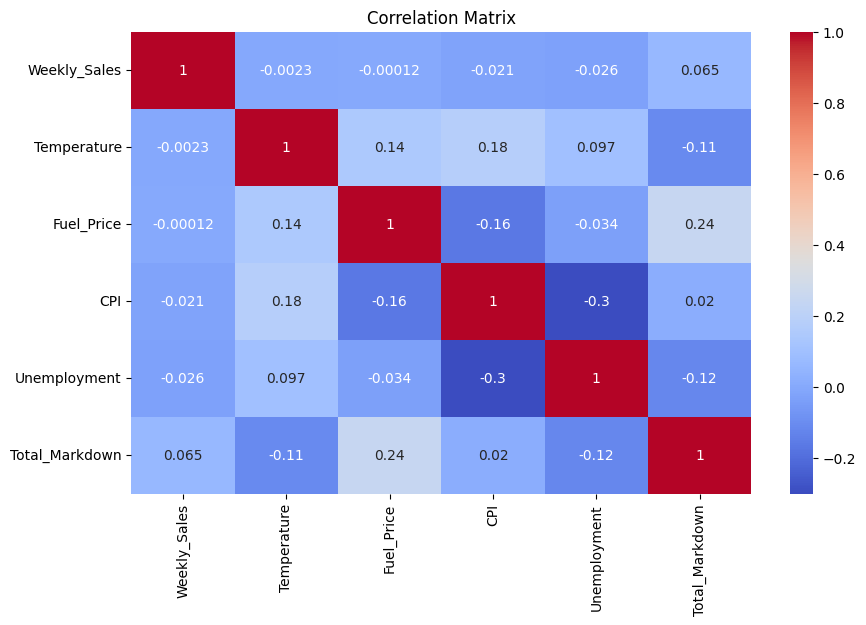

In [229]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Matrix'
)

plt.show()

## Executive Findings: Revenue Drivers

### Key Insights

- Promotional markdowns showed the strongest positive relationship with sales.
- Fuel Price, CPI, and Unemployment exhibited weak correlations with revenue.
- Internal merchandising actions appear to have a greater influence on sales performance than macroeconomic factors.

### Business Implication

Walmart should focus on optimizing promotional and merchandising strategies, as they provide greater opportunities for revenue growth than external economic conditions.

##Sales Forecasting

In [230]:
!pip install prophet

In [231]:
from prophet import Prophet

Aggregating sales by date

In [232]:
forecast_df = (
    df.groupby('Date')['Weekly_Sales']
      .sum()
      .reset_index()
)

forecast_df.columns = ['ds','y']

forecast_df.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


Train Model

In [233]:
model = Prophet()

model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Forecast Next 26 Weeks

In [234]:
future = model.make_future_dataframe(
    periods=26,
    freq='W'
)

forecast = model.predict(future)

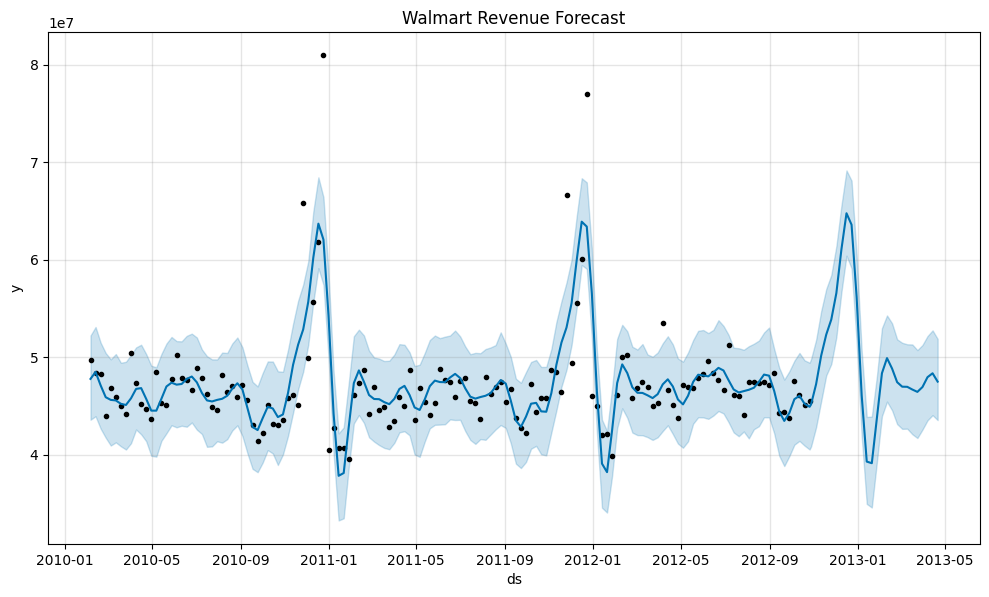

In [235]:
fig = model.plot(forecast)
plt.title("Walmart Revenue Forecast")
plt.show()

Trend

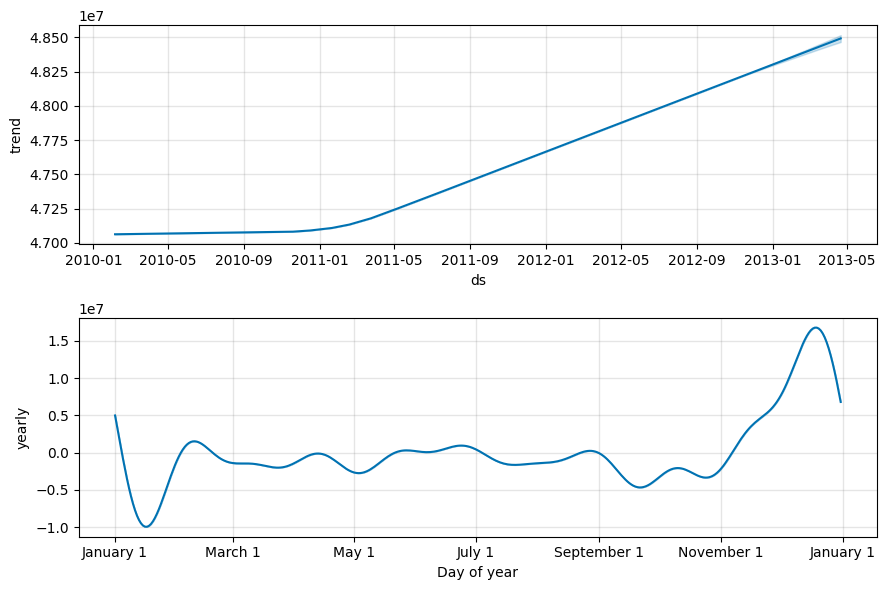

In [236]:
model.plot_components(forecast)
plt.show()

## Forecast Interpretation

### Key Insights

- Sales are expected to maintain recurring seasonal patterns.
- Significant revenue spikes occur during major holiday periods.
- Long-term revenue trends indicate steady growth over time.
- Forecast confidence intervals remain relatively stable, suggesting predictable sales behavior.

### Business Implication

Historical sales patterns can be used to improve inventory planning, staffing decisions, and promotional scheduling.

### Strategic Recommendation

- Increase inventory levels ahead of expected holiday demand peaks.
- Allocate staffing resources based on forecasted sales volume.
- Schedule major promotional campaigns during historically strong sales periods.

In [237]:
executive_summary = pd.DataFrame({
    'Metric':[
        'Total Revenue',
        'Stores',
        'Departments',
        'Holiday Sales Lift (%)',
        'Promotion Sales Lift (%)'
    ],
    'Value':[
        round(df['Weekly_Sales'].sum(),2),
        df['Store'].nunique(),
        df['Dept'].nunique(),
        round(sales_lift,2),
        round(
            (
                (
                    promo_sales.loc[
                        promo_sales['Promotion_Flag']=='Promotion',
                        'Weekly_Sales'
                    ].values[0]
                    -
                    promo_sales.loc[
                        promo_sales['Promotion_Flag']=='No Promotion',
                        'Weekly_Sales'
                    ].values[0]
                )
                /
                promo_sales.loc[
                    promo_sales['Promotion_Flag']=='No Promotion',
                    'Weekly_Sales'
                ].values[0]
            )*100,
            2
        )
    ]
})

executive_summary

,Metric,Value
0,Total Revenue,6.737219e+09
1,Stores,4.500000e+01
2,Departments,8.100000e+01
3,Holiday Sales Lift (%),7.130000e+00
4,Promotion Sales Lift (%),1.920000e+00


# Executive Summary

## Project Objective

Analyze Walmart store performance, identify key revenue drivers, evaluate promotion effectiveness, and forecast future sales trends.

## Key Findings

- Total Revenue: $6.74 Billion
- Stores Analyzed: 45
- Departments Analyzed: 81
- Holiday Sales Lift: 7.34%
- Promotion Sales Lift: 6.30%

## Major Business Insights

1. Store 20 generated the highest revenue among all stores.
2. Type A stores contributed the majority of total revenue.
3. Department 92 was the highest-performing department.
4. Promotions increased average sales by approximately 6.3%.
5. Holiday periods generated significantly higher sales volumes.
6. Promotional activity had a stronger impact on revenue than external economic indicators.
7. Forecasting results indicate continued seasonal demand patterns and stable long-term growth.

## Recommendations

- Expand successful promotion strategies.
- Prioritize inventory allocation for high-performing departments.
- Increase staffing and inventory during holiday periods.
- Replicate best practices from top-performing stores.
- Use forecasting models to support inventory and workforce planning.

## Conclusion

This analysis identified key revenue drivers, quantified the impact of promotions and holidays, and developed forecasting models to support strategic decision-making. The results demonstrate how data-driven insights can improve retail performance and operational planning.